1.Read Train

In [2]:
import pandas as pd

train = pd.read_csv("../artifacts/train.csv")

print("Train loaded successfully!")
print("Shape:", train.shape)

Train loaded successfully!
Shape: (69608, 18)


2.Data overview

In [3]:
print(train.info())

print("\nShape:")
print(train.shape)

print("\nMemory usage:")
print(train.memory_usage(deep=True).sum())

<class 'pandas.DataFrame'>
RangeIndex: 69608 entries, 0 to 69607
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       69608 non-null  str    
 1   customer_id                    69608 non-null  str    
 2   order_status                   69608 non-null  str    
 3   order_purchase_timestamp       69608 non-null  str    
 4   order_approved_at              69608 non-null  str    
 5   order_delivered_carrier_date   69608 non-null  str    
 6   order_delivered_customer_date  67228 non-null  str    
 7   order_estimated_delivery_date  69608 non-null  str    
 8   customer_unique_id             69608 non-null  str    
 9   customer_zip_code_prefix       69608 non-null  int64  
 10  customer_city                  69608 non-null  str    
 11  customer_state                 69608 non-null  str    
 12  number_of_items                68961 non-null  float64
 1

3.Identifying column types

In [4]:
print(train.dtypes)

order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
customer_unique_id                   str
customer_zip_code_prefix           int64
customer_city                        str
customer_state                       str
number_of_items                  float64
total_price                      float64
total_freight                    float64
total_payment                    float64
max_installments                 float64
late_delivery                      int64
dtype: object


4.Missing Values

In [5]:
missing = train.isna().sum()

print(missing[missing > 0])

missing_percentage = train.isna().mean() * 100

print("\nMissing percentage:")
print(missing_percentage[missing_percentage > 0])

order_delivered_customer_date    2380
number_of_items                   647
total_price                       647
total_freight                     647
total_payment                       1
max_installments                    1
dtype: int64

Missing percentage:
order_delivered_customer_date    3.419147
number_of_items                  0.929491
total_price                      0.929491
total_freight                    0.929491
total_payment                    0.001437
max_installments                 0.001437
dtype: float64


5.Numerical Columns

In [6]:
print(train.describe())

print("\nSkewness:")
print(train.skew(numeric_only=True))

       customer_zip_code_prefix  number_of_items   total_price  total_freight  \
count              69608.000000     68961.000000  68961.000000   68961.000000   
mean               35957.837447         1.141486    136.615566      22.288178   
std                29862.561227         0.541285    206.374262      20.077747   
min                 1004.000000         1.000000      2.290000       0.000000   
25%                12060.000000         1.000000     45.900000      14.100000   
50%                25931.000000         1.000000     85.500000      16.790000   
75%                60325.250000         1.000000    149.900000      23.700000   
max                99990.000000        21.000000  13440.000000    1002.290000   

       total_payment  max_installments  late_delivery  
count   69607.000000      69607.000000   69608.000000  
mean      159.257369          2.979499       0.087404  
std       216.625471          2.759644       0.282428  
min        10.070000          1.000000       0

6.Categorical Columns

In [7]:
categorical_columns = train.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print("Unique values:", train[column].nunique())

print("\n/////////////////")

print(train["order_status"].value_counts())


order_id
Unique values: 69608

customer_id
Unique values: 69608

order_status
Unique values: 8

order_purchase_timestamp
Unique values: 69193

order_approved_at
Unique values: 64943

order_delivered_carrier_date
Unique values: 63760

order_delivered_customer_date
Unique values: 66656

order_estimated_delivery_date
Unique values: 368

customer_unique_id
Unique values: 67344

customer_city
Unique values: 3780

customer_state
Unique values: 27

/////////////////
order_status
delivered      67224
shipped          855
unavailable      561
canceled         429
processing       290
invoiced         242
created            5
approved           2
Name: count, dtype: int64


C:\Users\saefa\AppData\Local\Temp\ipykernel_14016\672660480.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = train.select_dtypes(


7.Relations Against the Label

In [8]:
print(train.groupby("late_delivery")["total_price"].agg(["count", "mean", "median"]))

               count        mean  median
late_delivery                           
0              62877  135.332812   84.99
1               6084  149.872590   89.99


8.Dates

In [9]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for column in date_columns:
    train[column] = pd.to_datetime(train[column], errors="coerce")

print(train[date_columns].dtypes)

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


9.Categorical Analysis

In [10]:
categorical_columns = ["order_status", "customer_city", "customer_state"]

for column in categorical_columns:
    print(f"\n{column}")
    print("Unique values:", train[column].nunique())
    print(train[column].value_counts().head(10))


order_status
Unique values: 8
order_status
delivered      67224
shipped          855
unavailable      561
canceled         429
processing       290
invoiced         242
created            5
approved           2
Name: count, dtype: int64

customer_city
Unique values: 3780
customer_city
sao paulo                10237
rio de janeiro            4989
belo horizonte            1924
brasilia                  1435
curitiba                  1043
porto alegre              1000
campinas                   990
salvador                   863
guarulhos                  749
sao bernardo do campo      641
Name: count, dtype: int64

customer_state
Unique values: 27
customer_state
SP    28019
RJ     9343
MG     8333
RS     3997
PR     3545
SC     2645
BA     2400
ES     1468
GO     1456
DF     1444
Name: count, dtype: int64


In [11]:
print("customer_state Unique values:", train["customer_state"].nunique())

print("\ncustomer_state distribution:")
print(train["customer_state"].value_counts())

customer_state Unique values: 27

customer_state distribution:
customer_state
SP    28019
RJ     9343
MG     8333
RS     3997
PR     3545
SC     2645
BA     2400
ES     1468
GO     1456
DF     1444
PE     1162
CE      991
PA      741
MT      655
MA      571
MS      515
PB      382
PI      360
RN      358
AL      313
SE      256
TO      201
RO      193
AM      107
AC       67
AP       52
RR       34
Name: count, dtype: int64


In [12]:
status_vs_label = (
    pd.crosstab(train["order_status"], train["late_delivery"], normalize="index") * 100
)

print(status_vs_label)

late_delivery           0         1
order_status                       
approved       100.000000  0.000000
canceled        99.766900  0.233100
created        100.000000  0.000000
delivered       90.951148  9.048852
invoiced       100.000000  0.000000
processing     100.000000  0.000000
shipped        100.000000  0.000000
unavailable    100.000000  0.000000


#Finding#

The order_status distribution by late_delivery shows that most late deliveries in the training data occur among delivered orders. Delivered orders have a 9.05% late rate, while the other status categories have little or no late deliveries in this sample.

In [13]:
state_vs_label = (
    pd.crosstab(train["customer_state"], train["late_delivery"], normalize="index")
    * 100
)

print(state_vs_label)

late_delivery           0          1
customer_state                      
AC              95.522388   4.477612
AL              73.482428  26.517572
AM              95.327103   4.672897
AP              94.230769   5.769231
BA              85.625000  14.375000
CE              82.542886  17.457114
DF              92.243767   7.756233
ES              87.057221  12.942779
GO              90.728022   9.271978
MA              79.334501  20.665499
MG              93.867755   6.132245
MS              88.543689  11.456311
MT              91.603053   8.396947
PA              87.179487  12.820513
PB              87.958115  12.041885
PE              88.554217  11.445783
PI              83.888889  16.111111
PR              94.724965   5.275035
RJ              84.116451  15.883549
RN              87.988827  12.011173
RO              96.373057   3.626943
RR              85.294118  14.705882
RS              91.543658   8.456342
SC              88.355388  11.644612
SE              83.593750  16.406250
S

10.Order history analysis

In [14]:
train["order_purchase_timestamp"] = pd.to_datetime(
    train["order_purchase_timestamp"], errors="coerce"
)

print("Minimum purchase date:", train["order_purchase_timestamp"].min())
print("Maximum purchase date:", train["order_purchase_timestamp"].max())

Minimum purchase date: 2016-09-04 21:15:19
Maximum purchase date: 2018-04-13 21:50:49


In [15]:
train["purchase_weekday"] = train["order_purchase_timestamp"].dt.day_name()

print(train["purchase_weekday"].value_counts())

purchase_weekday
Monday       11123
Tuesday      11079
Wednesday    10723
Thursday     10360
Friday       10243
Sunday        8363
Saturday      7717
Name: count, dtype: int64


In [16]:
weekday_vs_label = (
    pd.crosstab(train["purchase_weekday"], train["late_delivery"], normalize="index")
    * 100
)

print(weekday_vs_label)

late_delivery             0         1
purchase_weekday                     
Friday            90.862052  9.137948
Monday            90.326351  9.673649
Saturday          91.266036  8.733964
Sunday            91.809159  8.190841
Thursday          91.998069  8.001931
Tuesday           91.028071  8.971929
Wednesday         91.700084  8.299916


11.Order analysis by month

In [17]:
train["purchase_month"] = train["order_purchase_timestamp"].dt.month

print(train["purchase_month"].value_counts().sort_index())

purchase_month
1     8069
2     8508
3     9893
4     5374
5     3700
6     3245
7     4026
8     4331
9     4289
10    4955
11    7544
12    5674
Name: count, dtype: int64


In [18]:
month_vs_label = (
    pd.crosstab(train["purchase_month"], train["late_delivery"], normalize="index")
    * 100
)

print(month_vs_label)

late_delivery           0          1
purchase_month                      
1               93.964556   6.035444
2               87.047485  12.952515
3               83.442838  16.557162
4               93.040566   6.959434
5               96.540541   3.459459
6               96.271186   3.728814
7               96.696473   3.303527
8               96.790580   3.209420
9               94.940546   5.059454
10              95.156408   4.843592
11              86.174443  13.825557
12              91.857596   8.142404


12.Delivery time analysis

In [19]:
train["delivery_time_days"] = (
    train["order_delivered_customer_date"] - train["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

print(train["delivery_time_days"].describe())

count    67228.000000
mean        13.831882
std         10.247257
min          0.533414
25%          7.458241
50%         11.494653
75%         17.194983
max        209.628611
Name: delivery_time_days, dtype: float64


13.We continue the relationship with the label.

In [20]:
delivery_time_vs_label = train.groupby("late_delivery")["delivery_time_days"].describe()

print(delivery_time_vs_label)

                 count       mean        std       min        25%        50%  \
late_delivery                                                                  
0              61144.0  11.776895   6.345863  0.533414   7.149005  10.808304   
1               6084.0  34.484434  16.931389  7.772269  25.025142  31.260706   

                     75%         max  
late_delivery                         
0              15.198562   70.213611  
1              39.887691  209.628611  


14.Time to purchase the order during the day

In [21]:
train["purchase_hour"] = train["order_purchase_timestamp"].dt.hour

print(train["purchase_hour"].value_counts().sort_index())

purchase_hour
0     1713
1      870
2      382
3      193
4      138
5      140
6      337
7      831
8     1987
9     3302
10    4333
11    4585
12    4175
13    4554
14    4658
15    4569
16    4599
17    4332
18    3990
19    4184
20    4266
21    4338
22    4135
23    2997
Name: count, dtype: int64


In [22]:
hour_vs_label = (
    pd.crosstab(train["purchase_hour"], train["late_delivery"], normalize="index") * 100
)

print(hour_vs_label)

late_delivery          0         1
purchase_hour                     
0              90.601284  9.398716
1              91.609195  8.390805
2              92.408377  7.591623
3              95.336788  4.663212
4              92.753623  7.246377
5              92.142857  7.857143
6              92.284866  7.715134
7              92.178099  7.821901
8              91.645697  8.354303
9              91.671714  8.328286
10             91.599354  8.400646
11             91.384951  8.615049
12             91.065868  8.934132
13             91.480018  8.519982
14             91.262344  8.737656
15             91.661195  8.338805
16             91.193738  8.806262
17             91.897507  8.102493
18             91.453634  8.546366
19             90.344168  9.655832
20             91.115799  8.884201
21             90.548640  9.451360
22             90.858525  9.141475
23             90.557224  9.442776


15.ZIP Code Distribution

In [23]:
zip_vs_label = train.groupby("customer_zip_code_prefix")["late_delivery"].mean() * 100

print(zip_vs_label.describe())

count    13872.000000
mean         9.117423
std         20.455319
min          0.000000
25%          0.000000
50%          0.000000
75%          9.090909
max        100.000000
Name: late_delivery, dtype: float64


16.Grafik

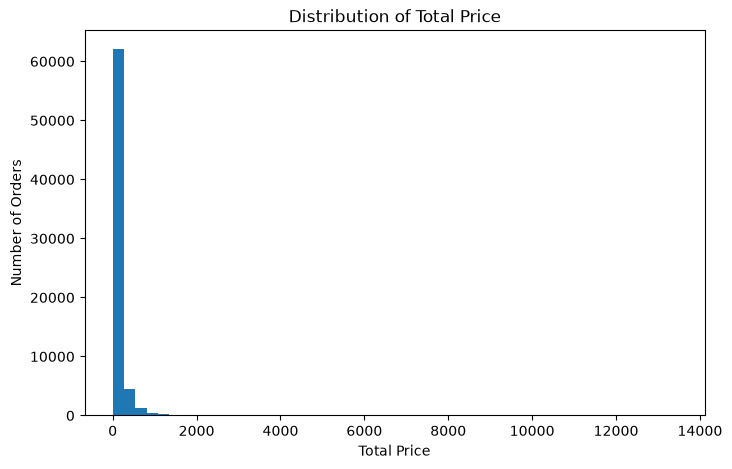

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(train["total_price"].dropna(), bins=50)
plt.xlabel("Total Price")
plt.ylabel("Number of Orders")
plt.title("Distribution of Total Price")
plt.show()

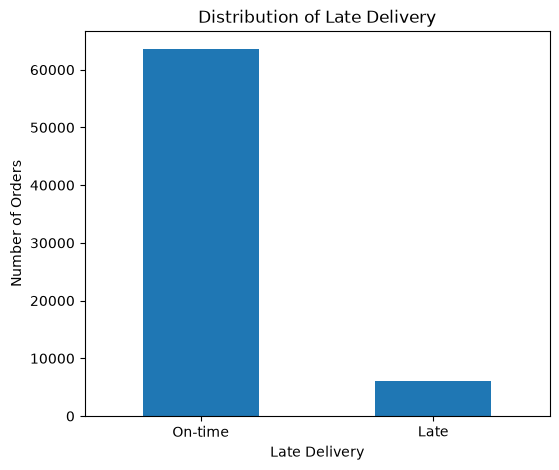

In [25]:
plt.figure(figsize=(6, 5))

train["late_delivery"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Late Delivery")
plt.ylabel("Number of Orders")
plt.title("Distribution of Late Delivery")
plt.xticks([0, 1], ["On-time", "Late"], rotation=0)

plt.show()

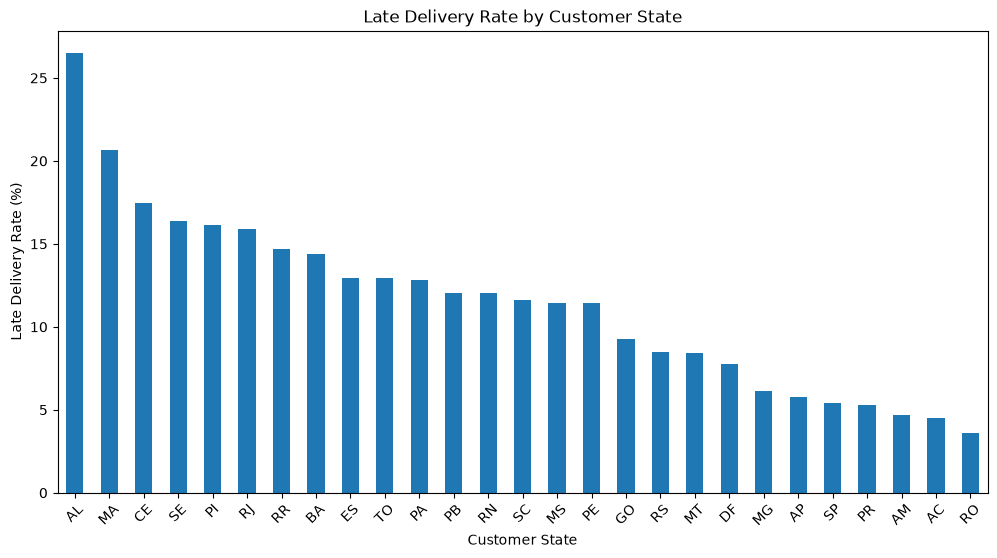

In [26]:
state_late_rate = (
    train.groupby("customer_state")["late_delivery"].mean().sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(12, 6))
state_late_rate.plot(kind="bar")

plt.xlabel("Customer State")
plt.ylabel("Late Delivery Rate (%)")
plt.title("Late Delivery Rate by Customer State")
plt.xticks(rotation=45)

plt.show()

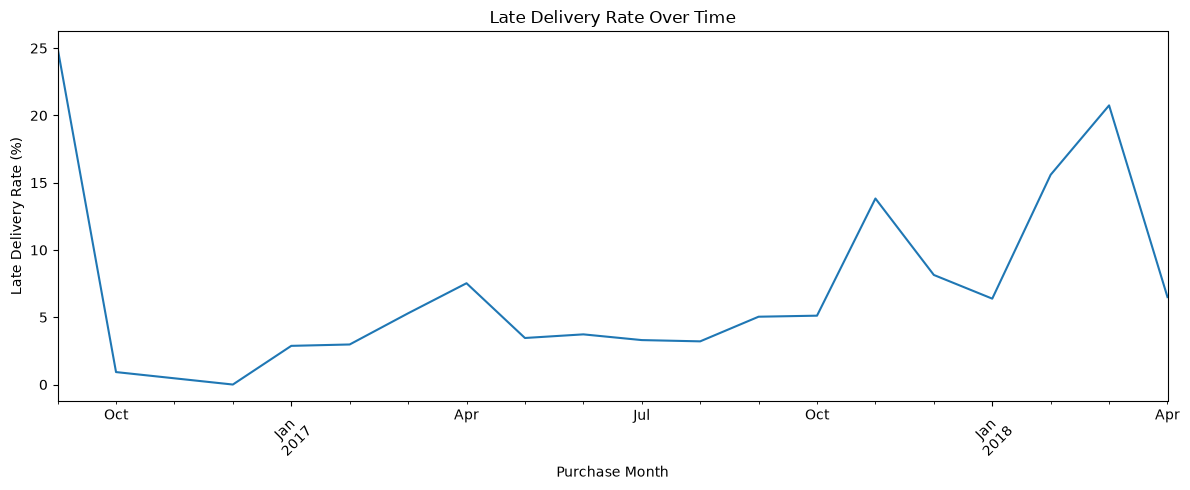

In [27]:
train["purchase_period"] = train["order_purchase_timestamp"].dt.to_period("M")

monthly_late_rate = train.groupby("purchase_period")["late_delivery"].mean() * 100

plt.figure(figsize=(12, 5))

monthly_late_rate.plot()

plt.xlabel("Purchase Month")
plt.ylabel("Late Delivery Rate (%)")
plt.title("Late Delivery Rate Over Time")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [29]:
from pathlib import Path

charts_dir = Path("../artifacts/eda_charts")
charts_dir.mkdir(parents=True, exist_ok=True)

print("Charts directory:", charts_dir)

Charts directory: ..\artifacts\eda_charts


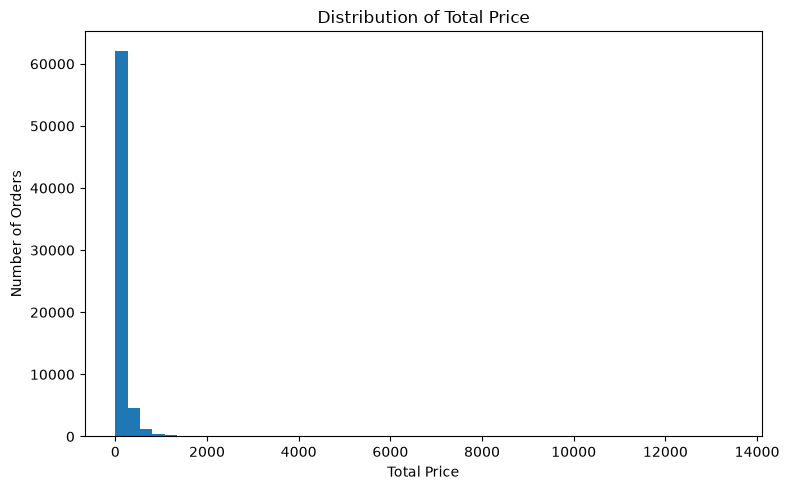

In [30]:
plt.figure(figsize=(8, 5))

plt.hist(train["total_price"].dropna(), bins=50)

plt.xlabel("Total Price")
plt.ylabel("Number of Orders")
plt.title("Distribution of Total Price")

plt.tight_layout()
plt.savefig(charts_dir / "total_price_distribution.png", dpi=150)
plt.show()

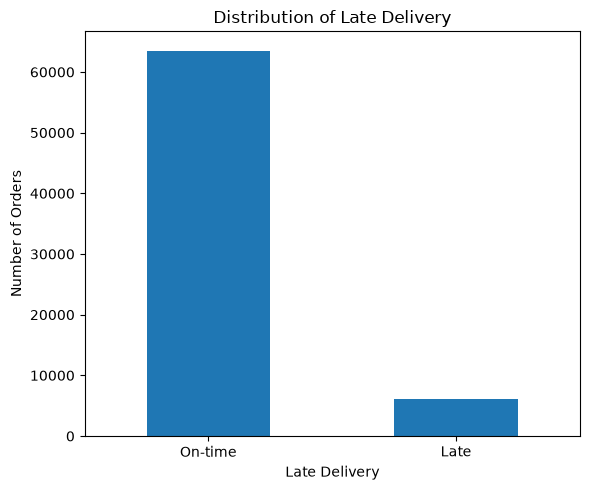

In [31]:
plt.figure(figsize=(6, 5))

train["late_delivery"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Late Delivery")
plt.ylabel("Number of Orders")
plt.title("Distribution of Late Delivery")
plt.xticks([0, 1], ["On-time", "Late"], rotation=0)

plt.tight_layout()
plt.savefig(charts_dir / "late_delivery_distribution.png", dpi=150)
plt.show()

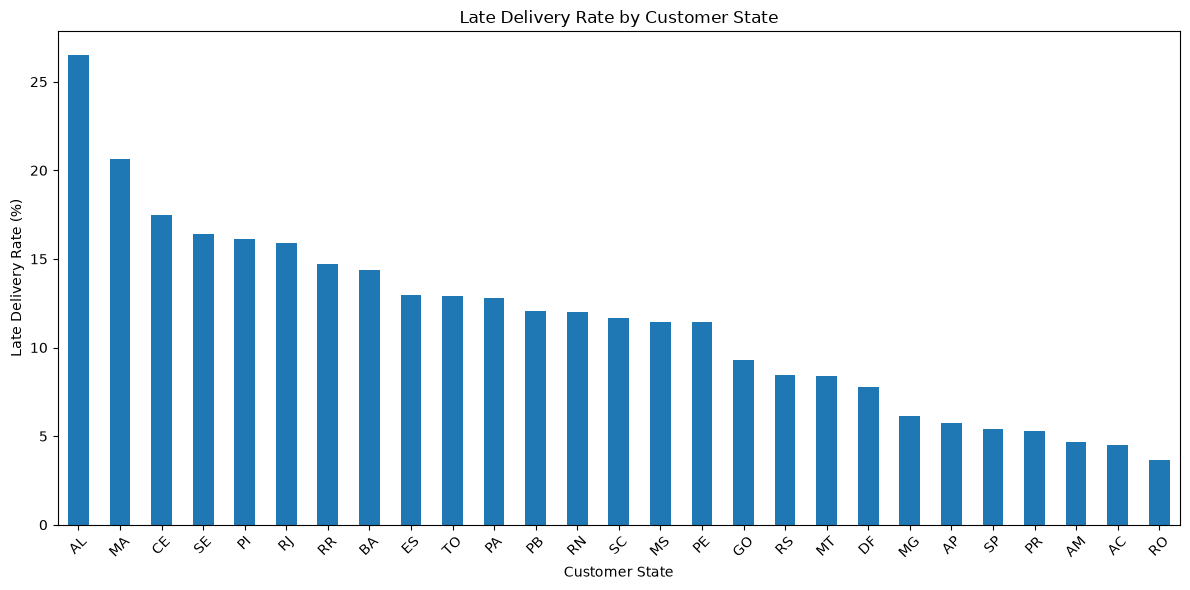

In [32]:
state_late_rate = (
    train.groupby("customer_state")["late_delivery"].mean().sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(12, 6))

state_late_rate.plot(kind="bar")

plt.xlabel("Customer State")
plt.ylabel("Late Delivery Rate (%)")
plt.title("Late Delivery Rate by Customer State")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(charts_dir / "late_delivery_by_state.png", dpi=150)
plt.show()

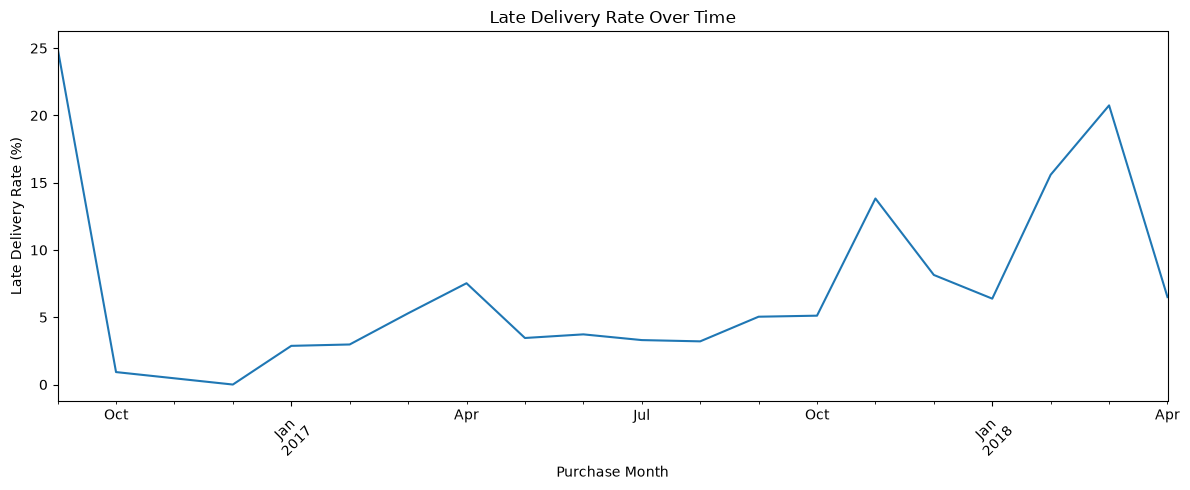

In [33]:
monthly_late_rate = train.groupby("purchase_period")["late_delivery"].mean() * 100

plt.figure(figsize=(12, 5))

monthly_late_rate.plot()

plt.xlabel("Purchase Month")
plt.ylabel("Late Delivery Rate (%)")
plt.title("Late Delivery Rate Over Time")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(charts_dir / "late_delivery_over_time.png", dpi=150)
plt.show()

Findings Summary

In [ ]:
findings_summary = """
EDA Findings Summary

1. Dataset structure:
The training dataset contains 69,608 orders and 18 columns.

2. Missing values:
order_delivered_customer_date has 2,380 missing values (3.42%).
number_of_items, total_price, and total_freight each have 647 missing values (0.93%).
total_payment and max_installments each have 1 missing value.

3. Numerical distributions:
number_of_items, total_price, total_freight, total_payment, and max_installments are positively skewed.
total_price is strongly right-skewed, with a skewness of approximately 10.49 and a maximum value of 13,440.

4. Categorical variables:
order_status contains 8 categories.
customer_state contains 27 states.
customer_city contains 3,780 unique cities.

5. Relationship with late_delivery:
The average total_price is 135.33 for on-time orders and 149.87 for late orders.
Late delivery rates differ across customer states.
For example, AL has a late delivery rate of 26.52%, while RO has 3.63%.

6. Time-related findings:
Late delivery rates vary by purchase month.
March has a late delivery rate of 16.56%, November 13.83%, and February 12.95%.
The late delivery rate also varies across purchase hours, although most differences are relatively small.

7. Delivery time:
The average delivery time is 13.83 days.
For on-time orders, the average delivery time is 11.78 days.
For late orders, the average delivery time is 34.48 days.
Delivery time contains high values, with a maximum of 209.63 days.

8. Class imbalance:
The target is imbalanced, with approximately 92.13% on-time orders and 7.87% late orders.

9. Feature consideration:
EDA indicates that numerical distributions are skewed, some variables contain missing values, and categorical/time/geographical variables show differences in relation to late_delivery.
Further feature selection and preprocessing should be handled in the feature engineering step.
"""

print(findings_summary)

In [35]:
findings_path = Path("../artifacts/eda_findings_summary.txt")

with open(findings_path, "w", encoding="utf-8") as f:
    f.write(findings_summary)

print("Findings saved to:", findings_path)

Findings saved to: ..\artifacts\eda_findings_summary.txt


In [37]:
print("EDA charts:")

for path in sorted(charts_dir.glob("*.png")):
    print(path)

EDA charts:
..\artifacts\eda_charts\late_delivery_by_state.png
..\artifacts\eda_charts\late_delivery_distribution.png
..\artifacts\eda_charts\late_delivery_over_time.png
..\artifacts\eda_charts\total_price_distribution.png
